In [17]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config

In [18]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO


In [19]:

cfg = Config()

mass_func = MassFuncSheth1999()

smooth_profile = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_profile = ProfileNFW(ConcentrationPieri2009_clumps(ConcentrationNeto2007(cfg), d_vir=0.3), 
                           R_virSO(cfg))

clump_distribution = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))
clump_mass_func = ClumpMassGiocoli2010(cfg)

In [20]:
from halo_model.power_spectra.Pm_computer import Pm_computer

In [21]:
Pm_std = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

dict_std = Pm_computer(Pm_std, k_vals)
    

interpolating Ic and Jc functions...


In [22]:
k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_m0s = []

for m0 in [1e7, 1e8, 1e9, 1e10]:
    cfg_temp = copy.deepcopy(cfg)
    cfg_temp.m0 = m0
    cfg_temp.beta = -1
    clump_mass_func = ClumpMassGiocoli2010_mod(cfg_temp)

    Pm = MatterPower(cfg_temp, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)
    
    Pm_m0s.append(Pm)

P_m0_dicts = []

for Pm in Pm_m0s:
    P_m0_dicts.append(Pm_computer(Pm, k_vals))


interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...


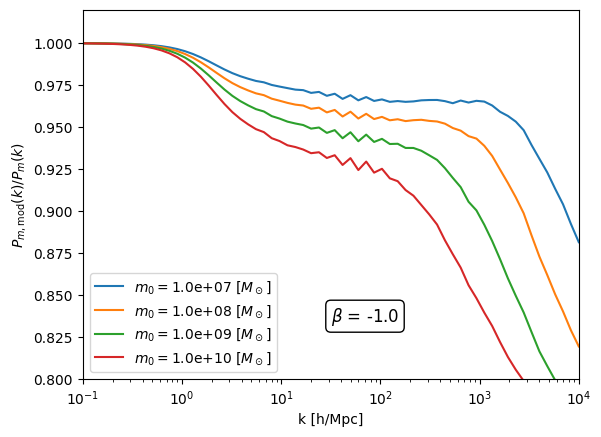

In [23]:
for i, dict_ in enumerate(P_m0_dicts):
    plt.plot(k_vals, dict_['P_1h']/dict_std['P_1h'], label=r'$m_0 =$' + f'{Pm_m0s[i].cfg.m0:.1e} ' +r'$[M_\odot$]')
        
plt.xscale("log")
plt.ylim(0.8, 1.02)
plt.xlim(np.min(k_vals), np.max(k_vals))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()

plt.text(
    0.5, 0.2,
    r"$\beta$" +  f" = {Pm_m0s[i].cfg.beta:.1f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)

plt.savefig("plots_Pm_modified_cmf/Pm_mod_m0.pdf")
plt.show()

In [24]:
k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_betas = []

for beta in [-0.1, -0.3, -0.5, -1]:
    cfg_local = copy.deepcopy(cfg)
    cfg_local.m0 = 2e9
    cfg_local.beta = beta

    clump_mass_func = ClumpMassGiocoli2010_mod(cfg_local.m0, beta=cfg_local.beta)

    Pm = MatterPower(cfg_local, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)
    
    Pm_betas.append(Pm)
    
P_beta_dicts = []

for Pm in Pm_betas:
    P_beta_dicts.append(Pm_computer(Pm, k_vals))

TypeError: ClumpMassGiocoli2010_mod.__init__() got an unexpected keyword argument 'beta'

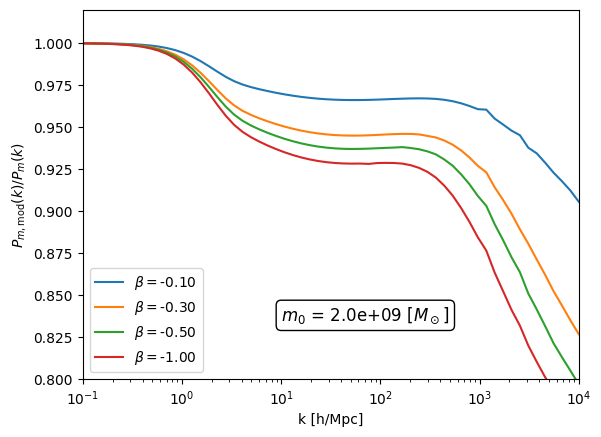

In [ ]:
for i, dict_ in enumerate(P_beta_dicts):

    plt.plot(k_vals, dict_['P_1h']/dict_std['P_1h'], label=r'$\beta =$' + f'{Pm_betas[i].cfg.beta:.2f}')
        
plt.xscale("log")
plt.ylim(0.8, 1.02)
plt.xlim(np.min(k_vals), np.max(k_vals))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()

plt.text(
    0.4, 0.2,
    r"$m_0$" +  f" = {Pm_betas[i].cfg.m0:.1e} " + r"$[M_\odot]$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)
plt.savefig("plots_Pm_modified_cmf/Pm_mod_beta.pdf")
plt.show()